In [8]:
import numpy as np
import matplotlib.pyplot as plt
from Utilities_copy import extractor
import uproot
import awkward as ak    

x_MH175=extractor("/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH175_LH_2017.root", "Events")


file=uproot.open("/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH175_LH_2017.root")
tree=file["Events"]
booleans= tree.arrays(["FatJet_isMatchedWithA"], library="ak")
booleanas=tree.arrays(["FatJet_isMatchedWith2BHadrons"], library="ak")
Fatjet_isMatchedWithA= booleans["FatJet_isMatchedWithA"]
Fatjet_isMatchedWith2BHadrons= booleanas["FatJet_isMatchedWith2BHadrons"]
#Filtriamo i dati

mask = (ak.flatten(Fatjet_isMatchedWithA) == 1) & (ak.flatten(Fatjet_isMatchedWith2BHadrons) == 1)
x_filtered = x_MH175[mask]

from scipy.special import voigt_profile
from iminuit import Minuit
from iminuit.cost import LeastSquares

x_plot=list(x_filtered)
x_plot.sort()
x_easy=[x for x in x_plot if 100 < x < 250]

def voigt2(x, norm, mu, sigma, gamma, norm2, mu2, sigma2, gamma2):
    return voigt_profile(x-mu, sigma, gamma) * norm + norm2*voigt_profile(x-mu2, sigma2, gamma2)

bin_counts, bin_edges = np.histogram(x_easy, bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
bin_densities = bin_counts / (len(x_easy) * bin_width)  # Densità normalizzata
yerr=np.sqrt(bin_counts) / (len(x_easy) * bin_width) # Errore standard per i dati binned

ls_voigt=LeastSquares(bin_centers, bin_densities, yerr, model=voigt2)

m_voigt=Minuit(ls_voigt,  norm=1, mu=175, sigma=5, gamma=1, norm2=1, mu2=175, sigma2=5, gamma2=0.001)
m_voigt.limits["mu"]= (125, 225)
m_voigt.limits["sigma"]= (0.1, 20)
m_voigt.limits["gamma"]= (0.01, 10)
m_voigt.fixed["gamma2"]= True

m_voigt.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 107.5 (χ²/ndof = 2.5)      │              Nfcn = 590              │
│ EDM = 6.15e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ norm   │   0.759   │   0.023   │            │            │         │         │       │
│ 1 │ mu     │  180.07   │   0.14    │            │            │   125   │   225   │       │
│ 2 │ sigma  │   11.15   │   0.20    │            │            │   0.1   │   20    │       │
│ 3 │ gamma  │   2.90    │   0.22    │            │            │  0.01   │   10    │       │
│ 4 │ norm2  │   0.259   │   0.021   │            │            │         │         │       │
│ 5 │ mu2    │   161.8   │    1.4    │            │            │         │         │       │
│ 6 │ sigma2 │   23.5    │    0.6    │            │            │         │         │       │
│ 7 │ gamma2 │  1.00e-3  │  0.01e-3  │            │            │         │         │  yes  │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────────┬─────────────────────────────────────────────────────────────────────────┐
│        │     norm       mu    sigma    gamma    norm2      mu2   sigma2   gamma2 │
├────────┼─────────────────────────────────────────────────────────────────────────┤
│   norm │  0.00051  -0.8e-3   1.9e-3   2.7e-3  -0.5e-3 -29.2e-3  -7.1e-3        0 │
│     mu │  -0.8e-3   0.0207   -0.013    0.005   0.8e-3    0.023   -0.035    0.000 │
│  sigma │   1.9e-3   -0.013   0.0414    -0.02  -2.0e-3    -0.12     0.02     0.00 │
│  gamma │   2.7e-3    0.005    -0.02   0.0478  -2.3e-3    -0.14    -0.09     0.00 │
│  norm2 │  -0.5e-3   0.8e-3  -2.0e-3  -2.3e-3 0.000441  27.6e-3   6.4e-3        0 │
│    mu2 │ -29.2e-3    0.023    -0.12    -0.14  27.6e-3      1.9     0.48      0.0 │
│ sigma2 │  -7.1e-3   -0.035     0.02    -0.09   6.4e-3     0.48    0.338     0.00 │
│ gamma2 │        0    0.000     0.00     0.00        0      0.0     0.00        0 │
└────────┴─────────────────────────────────────────────────────────────────────────┘

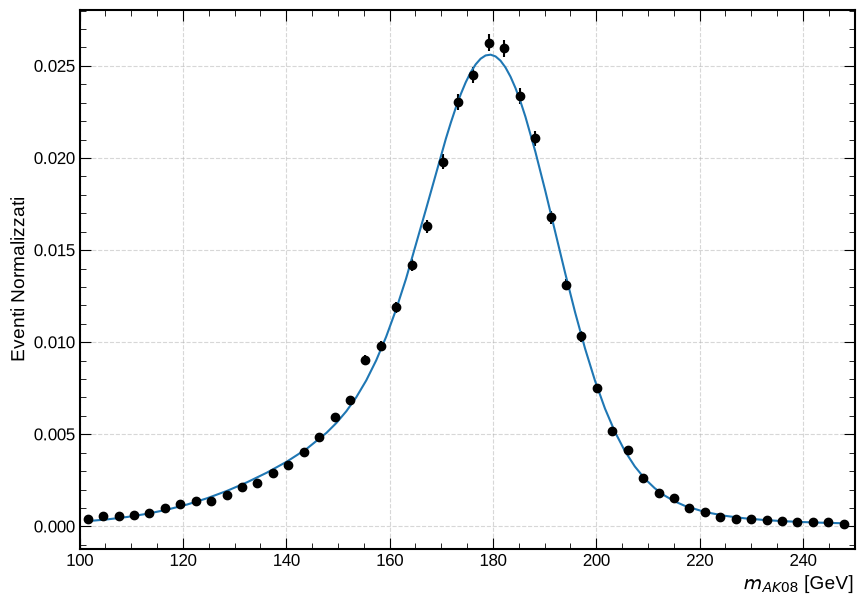

In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator


plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'DejaVu Sans'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
})

fix, ax= plt.subplots(figsize=(10, 7))



m_voigt.visualize()
#plt.legend(loc= "upper right", fontsize=14, frameon=True, framealpha=0.9, title="Fit ottimizzato con Minuit")
ax.set_xlabel(r"$m_{AK08}$ [GeV]", fontsize=14, loc="right")
ax.set_ylabel("Eventi Normalizzati", fontsize=14)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlim(100, 250)
ax.grid(True, linestyle='--', alpha=0.5)
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Double_Voigt_Minuit_175', bbox_inches='tight')

In [10]:
fit_MH175_values={}
fit_MH175_errors={}

fit_values={'MH175': fit_MH175_values,}
fit_errors={'MH175_errors': fit_MH175_errors}



for param in m_voigt.parameters:
    fit_MH175_values[param] = m_voigt.values[param]

for error in m_voigt.parameters:   
    fit_MH175_errors[error] = m_voigt.errors[error]

print(fit_MH175_values)
print(fit_MH175_errors)

import json
#QUi sono andato di metodo oragutang, ho deciso di voler fare 2 file separati peer errori e valori 
#Ho tenuto lo stesso quello con tutti i valori, casomai cambiassi idea

with open("fit_results.json", "r") as f:
    results=json.load(f)

with open("fit_values.json", "r") as g:
    values=json.load(g) 

with open("fit_errors.json", "r") as h:
    errors=json.load(h)


results["MH175"]=fit_MH175_values
results["MH175_errors"]=fit_MH175_errors

with open("fit_results.json", "w") as f:
    json.dump(results, f, indent=1)

values["MH175"]=fit_MH175_values
with open("fit_values.json", "w") as g:
    json.dump(values, g, indent=1)  

errors["MH175_errors"]=fit_MH175_errors
with open("fit_errors.json", "w") as h:
    json.dump(errors, h, indent=1)  

{'norm': 0.7587725225890556, 'mu': 180.06642923175443, 'sigma': 11.145471247451864, 'gamma': 2.904241183015285, 'norm2': 0.2591955442638899, 'mu2': 161.80254028980946, 'sigma2': 23.5492147874244, 'gamma2': 0.001}
{'norm': 0.022584262140787206, 'mu': 0.14395644867929036, 'sigma': 0.2035556828492453, 'gamma': 0.21859820810811437, 'norm2': 0.021010980272228273, 'mu2': 1.3766950374844793, 'sigma2': 0.581549419554561, 'gamma2': 1e-05}
